<a href="https://colab.research.google.com/github/raihanrachi/citra-digital-/blob/main/citra_digital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

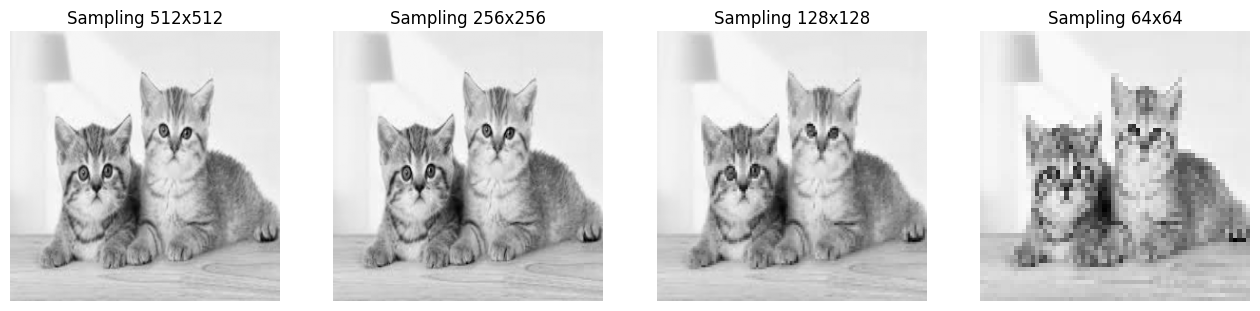

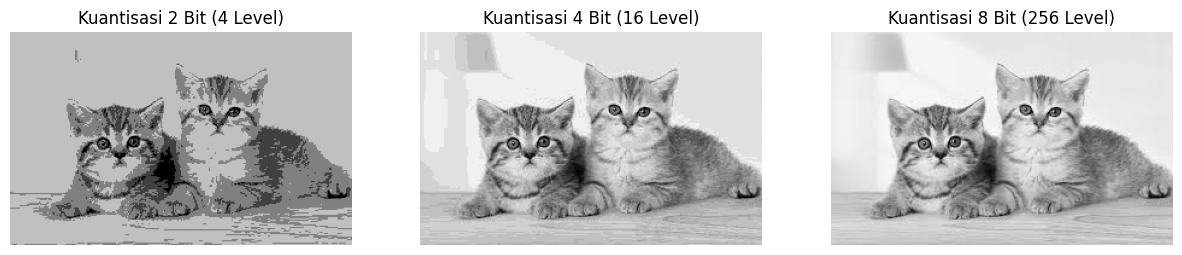

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request

# --- PERSIAPAN FILE ---
# Mengunduh gambar contoh dan menamainya 'images.jpg' jika belum ada
if not os.path.exists('images.jpg'):
    url = 'https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg'
    urllib.request.urlretrieve(url, 'images.jpg')
    print("Gambar 'images.jpg' berhasil disiapkan!")

# Membaca gambar dalam mode Grayscale
img_gray = cv2.imread('images.jpg', cv2.IMREAD_GRAYSCALE)

if img_gray is None:
    print("Error: File 'images.jpg' tidak ditemukan. Pastikan file sudah ada di folder Files (kiri).")
else:
    # --- NOMOR 2: SAMPLING (RESIZE) ---
    # Melakukan resize ke ukuran 512, 256, 128, dan 64
    sizes = [512, 256, 128, 64]
    plt.figure(figsize=(16, 4))

    for i, s in enumerate(sizes):
        img_resized = cv2.resize(img_gray, (s, s))
        plt.subplot(1, 4, i+1)
        plt.imshow(img_resized, cmap='gray')
        plt.title(f'Sampling {s}x{s}')
        plt.axis('off')
    plt.show()

    # --- NOMOR 3: KUANTISASI ---
    # Fungsi untuk mengubah bit depth (level keabuan)
    def quantize(image, bits):
        levels = 2**bits
        interval = 256 // levels
        res = (image // interval) * interval
        return res

    bit_levels = [2, 4, 8] # 4 level, 16 level, 256 level
    plt.figure(figsize=(15, 5))

    for i, b in enumerate(bit_levels):
        img_quantized = quantize(img_gray, b)
        plt.subplot(1, 3, i+1)
        plt.imshow(img_quantized, cmap='gray', vmin=0, vmax=255)
        plt.title(f'Kuantisasi {b} Bit ({2**b} Level)')
        plt.axis('off')
    plt.show()

In [ ]:
import numpy as np
from scipy.ndimage import label

# Representasi matriks dari gambar soal
matrix = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0,1,1,0],
    [0,1,1,1,0,0,0,1,1,0],
    [0,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,1,1,0,0,1,1,1,0],
    [0,0,1,1,0,0,1,1,1,0],
    [0,0,0,0,0,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0]
])

# Struktur konektivitas untuk 4-connectivity (atas, bawah, kiri, kanan)
structure = [[0,1,0],
             [1,1,1],
             [0,1,0]]

# Menghitung jumlah objek
labeled_array, num_features = label(matrix, structure=structure)

print(f"Jumlah objek berdasarkan 4-connectivity adalah: {num_features}")

Jumlah objek berdasarkan 4-connectivity adalah: 4
